<a href="https://colab.research.google.com/github/tilangelo/ML.2025-26/blob/main/dz_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Кластеризация данных студентов (student-mat.csv)

Этот ноутбук адаптирован под ваш датасет `student-mat.csv` и выполняет задание:
1. Преобразование датасета (обработка категориальных признаков, сохранение `df_not_processed`, масштабирование).
2. K-Means кластеризация: присвоение метки кластера в `df_not_processed`, статистика, графики, объяснение, метрики.
3. Подбор оптимального числа кластеров методом локтя: график, статистика, метрики, объяснение.
4. DBSCAN: подбор параметров, метрики, статистика, объяснение.
5. Сравнение методов и вывод о том, какой метод подходит лучше.

**Инструкция:** запустите все ячейки последовательно. Ноутбук ожидает, что файл `student-mat.csv` находится в той же папке, где вы его запускаете (или укажите путь к файлу в переменной `DATA_PATH`).


In [ ]:

# Imports and load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# Path to dataset (change if needed)
DATA_PATH = "student-mat.csv"

# Load dataset
df = pd.read_csv(DATA_PATH, sep=',')
print("Loaded dataset shape:", df.shape)
df.head()


Loaded dataset shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:

# Быстрый обзор
print("Columns:", list(df.columns))
print("\nInfo:")
display(df.info())
print("\nDescribe (numerical):")
display(df.describe())

# Сохраняем непроцессированный DF
df_not_processed = df.copy()

# Разделение признаков
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("\nNumeric columns:", numeric_cols)
print("Categorical columns:", cat_cols)


Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null  

None


Describe (numerical):


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000



Numeric columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [ ]:

# Обработка категориальных признаков: One-Hot Encoding для категорий с небольшим числом уникальных значений.
# Для колонок с множеством уникальных значений можно рассмотреть Label Encoding или оставить как есть.

# Если категорий слишком много, можно оставить только наиболее значимые или выполнить frequency encoding.
max_unique_for_ohe = 15

ohe_cols = [c for c in cat_cols if df[c].nunique() <= max_unique_for_ohe]
other_cat_cols = [c for c in cat_cols if c not in ohe_cols]

print("One-hot columns:", ohe_cols)
print("Other categorical columns (left out of OHE):", other_cat_cols)

df_proc = df.copy()

#заполняем NA в кат\нум если есть
for c in df_proc.columns:
    if df_proc[c].dtype == 'object' or str(df_proc[c].dtype).startswith('category'):
        df_proc[c] = df_proc[c].fillna('NA')
    else:
        df_proc[c] = df_proc[c].fillna(df_proc[c].median())

# One-hot encode для выбранных кат колонок
df_proc = pd.get_dummies(df_proc, columns=ohe_cols, drop_first=True)

for c in df_proc.columns:
    if df_proc[c].dtype == 'object' or str(df_proc[c].dtype).startswith('category'):
        df_proc[c] = pd.factorize(df_proc[c])[0]

print("Processed dataframe shape:", df_proc.shape)

X_raw = df_proc.copy()

scaler = StandardScaler()
#вычисляем средние/стандартные отклонения по колонкам и преобразуем данные
X_scaled = scaler.fit_transform(X_raw)

X = pd.DataFrame(X_scaled, columns=X_raw.columns)
X.head()


One-hot columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Other categorical columns (left out of OHE): []
Processed dataframe shape: (395, 42)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,1.023046,1.143856,1.360371,0.792251,-0.042286,-0.449944,0.062194,-0.236010,0.801479,-0.540699,...,0.668496,-0.296908,2.597133,-1.257656,-0.919671,-1.017881,0.507899,0.23094,-2.232677,-0.708450
1,0.238380,-1.600009,-1.399970,-0.643249,-0.042286,-0.449944,1.178860,-0.236010,-0.097908,-0.540699,...,-1.495896,-0.296908,-0.385040,0.795130,-0.919671,-1.017881,-1.968894,0.23094,0.447893,-0.708450
2,-1.330954,-1.600009,-1.399970,-0.643249,-0.042286,3.589323,0.062194,-0.236010,-0.997295,0.583385,...,0.668496,-0.296908,2.597133,-1.257656,1.087346,-1.017881,0.507899,0.23094,0.447893,-0.708450
3,-1.330954,1.143856,-0.479857,-0.643249,1.150779,-0.449944,-1.054472,-1.238419,-0.997295,-0.540699,...,0.668496,-0.296908,-0.385040,0.795130,1.087346,0.982433,0.507899,0.23094,0.447893,1.411533
4,-0.546287,0.229234,0.440257,-0.643249,-0.042286,-0.449944,0.062194,-0.236010,-0.997295,-0.540699,...,-1.495896,-0.296908,-0.385040,0.795130,1.087346,-1.017881,0.507899,0.23094,-2.232677,-0.708450


In [ ]:

# (пример)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
#обучаем модель и предсказываем метки кластера для каждого наблюдения
labels_km = kmeans.fit_predict(X)

df_not_processed['kmeans_cluster'] = labels_km

print("KMeans (k=%d) cluster counts:" % k)
display(df_not_processed['kmeans_cluster'].value_counts())

#центры кластеров в пространстве признаков после масштабирования
centers = kmeans.cluster_centers_
print("Cluster centers shape:", centers.shape)

# средние значения числовых характеристик на кластер
display(df_not_processed.groupby('kmeans_cluster')[numeric_cols].mean().T)


KMeans (k=3) cluster counts:


,count
kmeans_cluster,
0,154
2,153
1,88


Cluster centers shape: (3, 42)


kmeans_cluster,0,1,2
age,16.545455,17.386364,16.450980
Medu,2.337662,2.034091,3.575163
Fedu,2.149351,1.829545,3.294118
traveltime,1.350649,1.875000,1.300654
studytime,2.214286,1.556818,2.130719
failures,0.123377,1.125000,0.091503
famrel,4.025974,3.863636,3.908497
freetime,3.064935,3.477273,3.267974
goout,2.876623,3.477273,3.130719
Dalc,1.162338,2.000000,1.503268


Inertia: 14969.470828399897
Silhouette score: 0.041318755020648065
Calinski-Harabasz score: 21.218099241759795


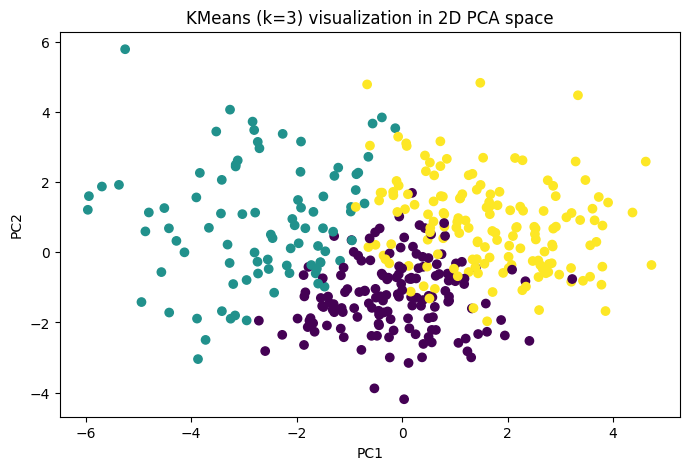

In [ ]:

# Метрики для kmeans

#сумма квадратов расстояний точек до их центров
inertia = kmeans.inertia_
#среднее расстояние между точками
sil = silhouette_score(X, labels_km)
#степень отделённости кластеров
ch = calinski_harabasz_score(X, labels_km)
print("Inertia:", inertia)
print("Silhouette score:", sil)
print("Calinski-Harabasz score:", ch)

from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_km)
plt.title(f"KMeans (k={k}) ")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()


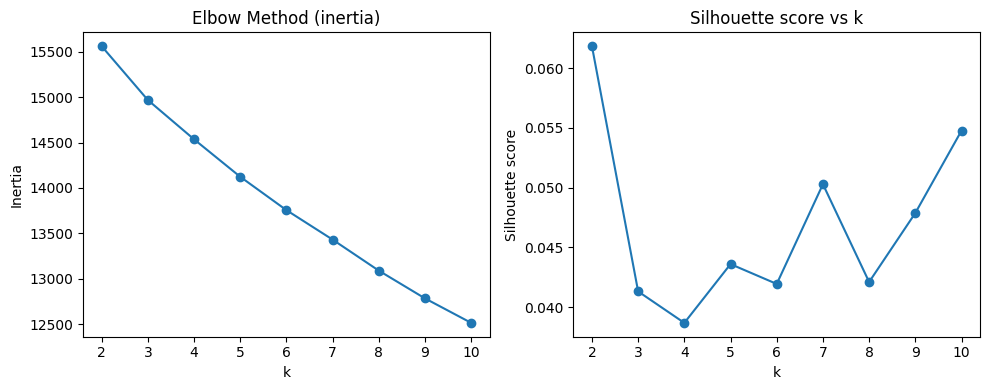

,k,inertia,silhouette
0,2,15563.052176,0.061833
8,10,12512.303184,0.054767
5,7,13430.277610,0.050287
7,9,12782.195164,0.047879
3,5,14123.231563,0.043606
6,8,13088.126084,0.042109
4,6,13755.338552,0.041946
1,3,14969.470828,0.041319
2,4,14536.352388,0.038689


In [ ]:

# Метод локтя: подбираем от 1 до 10 кластеров
inertias = []
sil_scores = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(list(K_range), inertias, marker='o')
plt.title('Elbow Method (inertia)')
plt.xlabel('k'); plt.ylabel('Inertia')

plt.subplot(1,2,2)
plt.plot(list(K_range), sil_scores, marker='o')
plt.title('Silhouette score vs k')
plt.xlabel('k'); plt.ylabel('Silhouette score')
plt.tight_layout()
plt.show()

# метрики
elbow_df = pd.DataFrame({'k': list(K_range), 'inertia': inertias, 'silhouette': sil_scores})
display(elbow_df.sort_values('silhouette', ascending=False))


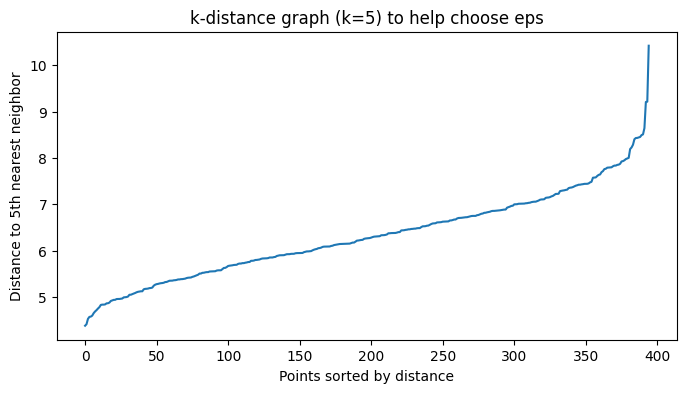


Best DBSCAN params by silhouette: None silhouette: -1
No suitable DBSCAN clustering found with the tried parameters.


In [ ]:

# DBSCAN tuning: используем график расстояний до k-соседа, чтобы подобрать eps
from sklearn.preprocessing import StandardScaler
X_for_db = X.copy()

#5 ближайших соседей для каждой точки
neigh = NearestNeighbors(n_neighbors=5)
#строим структуру
nbrs = neigh.fit(X_for_db)
#расстояния до 5 ближайших соседей, индексы этих соседей
distances, indices = nbrs.kneighbors(X_for_db)
# Для каждой точки берём расстояние до самого дальнего из 5 ближайших соседей
dist_k = np.sort(distances[:, -1])

plt.figure(figsize=(8,4))
plt.plot(dist_k)
plt.title('k-distance graph (k=5) to help choose eps')
plt.ylabel('Distance to 5th nearest neighbor')
plt.xlabel('Points sorted by distance')
plt.show()

# Try several DBSCAN params based on the elbow of the graph
eps_candidates = [0.5, 1.0, 1.5, 2.0]
min_samples_candidates = [3,5,7,10]

best = {'params': None, 'sil': -1, 'labels': None}
for eps in eps_candidates:
    for ms in min_samples_candidates:
        db = DBSCAN(eps=eps, min_samples=ms, metric='euclidean', n_jobs=-1)
        labels_db = db.fit_predict(X_for_db)
        # If all points in one cluster or all noise, skip
        if len(set(labels_db)) <= 1:
            continue
        try:
            sil = silhouette_score(X_for_db, labels_db)
            ch = calinski_harabasz_score(X_for_db, labels_db)
        except Exception as e:
            continue
        n_clusters = len([l for l in set(labels_db) if l != -1])
        print(f"eps={eps}, min_samples={ms} -> clusters (w/o noise) = {n_clusters}, silhouette={sil:.4f}, CH={ch:.1f}")
        if sil > best['sil']:
            best = {'params': (eps, ms), 'sil': sil, 'labels': labels_db}

print("\nBest DBSCAN params by silhouette:", best['params'], "silhouette:", best['sil'])


if best['labels'] is not None:
    df_not_processed['dbscan_cluster'] = best['labels']
    print("\nDBSCAN cluster value counts (including noise=-1):")
    display(df_not_processed['dbscan_cluster'].value_counts())
else:
    print("No suitable DBSCAN clustering found with the tried parameters.")



## Сравнение методов и выводы

- **K-Means** хорошо работает, если кластеры имеют примерно сферическую форму и одинаковую плотность. Он даёт стабильные центры и легко интерпретируем (центры кластера в пространстве признаков). Его метрики — inertia, silhouette, Calinski-Harabasz — помогают оценивать качество кластеризации.
- **DBSCAN** лучше выявляет кластеры произвольной формы и умеет выделять выбросы (noise, метка -1). Но он чувствителен к параметрам `eps` и `min_samples`. Для данных с разной плотностью кластеров DBSCAN может давать неудовлетворительные результаты.

**Рекомендация для `student-mat.csv`:** после анализа метрик и визуализации (PCA) выберите метод, который даёт более высокую silhouette score и более интерпретируемые кластеры с точки зрения предметной области (например, кластеры по успеваемости, посещаемости, характеристикам семейной среды и т.п.). Обычно для табличных данных с смешанными признаками сначала хорошо попробовать K-Means (с scaled features) и затем использовать DBSCAN как альтернативу для поиска выбросов/аномалий.

---

*Этот ноутбук сгенерирован автоматически на основе запроса. При необходимости могу расширить подбор параметров или встроить автоматическое объяснение кластеров (например, с помощью методов explainable ML).*
